In [1]:
import numpy as np
import pandas as pd
import os, re, math, platform
from pathlib import Path
import matplotlib.pyplot as plt
import json
import joblib
from scipy.stats import randint as sp_randint
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import matthews_corrcoef, confusion_matrix
from sklearn.metrics import precision_recall_curve, roc_curve, auc, fbeta_score
from imblearn.metrics import geometric_mean_score
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier 
from xgboost import plot_importance
from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier,ExtraTreesClassifier,AdaBoostClassifier
from sklearn.linear_model import SGDClassifier
#from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis as PA
from modlamp.descriptors import PeptideDescriptor, GlobalDescriptor
from matplotlib import pyplot
from sklearn.metrics import matthews_corrcoef, confusion_matrix,precision_recall_curve, roc_curve, auc, fbeta_score,roc_auc_score
from fea_extract import read_fasta,insert_AAC,insert_DPC,insert_CKSAAGP,insert_CTD,insert_PAAC,insert_AAI,insert_GTPC,insert_QSO,insert_AAE,insert_PSAAC,insert_word2int,insert_ASDC
import warnings 
from collections import Counter
from tools import cv,evaluate
import matplotlib.pyplot as plt
import seaborn as sns
Path('./results/balance_eval_AUC/').mkdir(exist_ok=True,parents=True)
warnings.filterwarnings('ignore')
seed=10

In [2]:
#!pip install lightgbm
from sklearn.ensemble import BaggingClassifier

In [3]:
def pro_data(seq):
    df_n = insert_PAAC(seq)
    df_n = insert_AAC(df_n)
    df_n = insert_CKSAAGP(df_n)
    df_n = insert_CTD(df_n)
    df_n = insert_DPC(df_n)
    df_n = insert_GTPC(df_n)
    df_n = insert_QSO(df_n)
    df_n = insert_AAE(df_n)
    df_n = insert_ASDC(df_n)
    #df_n = insert_word2int(df_n)
    return df_n

In [4]:
seq_X_train = pd.read_csv('data/train/X_train.csv')
seq_X_test = pd.read_csv('data/test/X_test.csv')
seq_y_train = pd.read_csv('data/train/y_train.csv')
seq_y_test = pd.read_csv('data/test/y_test.csv')

In [5]:
Seq_X_train = pro_data(seq_X_train)
Seq_X_test = pro_data(seq_X_test)

In [6]:
Seq_X_train

,Id,Sequence,Xc1.A,Xc1.R,Xc1.N,Xc1.D,Xc1.C,Xc1.Q,Xc1.E,Xc1.G,...,ASDC_390,ASDC_391,ASDC_392,ASDC_393,ASDC_394,ASDC_395,ASDC_396,ASDC_397,ASDC_398,ASDC_399
0,Sequence_194,GIGKFLKKAKKFGKAFVKILKK,0.447567,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.671350,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1,Sequence_581,GIPCAESCVWIPCTVTALVGCSCSDKVCYN,0.838062,0.000000,0.419031,0.419031,2.514186,0.000000,0.419031,0.838062,...,0.0,0.002299,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
2,Sequence_310,GLLSVLGSVAQHVLPHVVPVIAEHL,0.924585,0.000000,0.000000,0.000000,0.000000,0.462292,0.462292,0.924585,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
3,Sequence_177,VAKLLAKLAKKLL,0.732956,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
4,Sequence_632,GASCGETCFTGICFTAGCSCNPWPTCTRN,0.812329,0.406164,0.812329,0.000000,2.436986,0.000000,0.406164,1.624658,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1358,Sequence_370,RILSILRHQNLLKELQDLALQGAK,0.578498,0.578498,0.289249,0.289249,0.000000,0.867747,0.289249,0.289249,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1359,Sequence_321,QKIAEKFSGTRRG,0.205094,0.410187,0.000000,0.000000,0.000000,0.205094,0.205094,0.410187,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1360,Sequence_528,GIFGKILGVGKKVLCGLSGVC,0.000000,0.000000,0.000000,0.000000,0.609029,0.000000,0.000000,1.827088,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1361,Sequence_126,GLGKAQCAALWLQCASGGTIGCGGGAVACQNYRQFCR,2.216133,0.738711,0.369355,0.000000,1.846777,1.477422,0.000000,2.954843,...,0.0,0.000000,0.0,0.001502,0.003003,0.0,0.0,0.0,0.0,0.0


In [7]:
Seq_X_test

,Id,Sequence,Xc1.A,Xc1.R,Xc1.N,Xc1.D,Xc1.C,Xc1.Q,Xc1.E,Xc1.G,...,ASDC_390,ASDC_391,ASDC_392,ASDC_393,ASDC_394,ASDC_395,ASDC_396,ASDC_397,ASDC_398,ASDC_399
0,Sequence_574,CHHNLTAAC,1.140784,0.000000,0.570392,0.000000,1.140784,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,Sequence_623,ALFSILRGLKKLGNMGQAFVNCKIYKKC,0.539802,0.269901,0.539802,0.000000,0.539802,0.269901,0.000000,0.809703,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,Sequence_359,ALSILKGLEKLAKMGIALTNCKATKKC,1.274141,0.000000,0.318535,0.000000,0.637070,0.000000,0.318535,0.637070,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,Sequence_538,KWKLFKKIKFLHSAKKF,0.233863,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,Sequence_53,WFKKIPKFLHLLKKF,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,Sequence_85,ILKKWPWWPWRRK,0.000000,0.389180,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
337,Sequence_236,GIGASILSAGKSALKGFAKGLAEHFAN,1.806883,0.000000,0.301147,0.000000,0.000000,0.000000,0.301147,1.505736,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
338,Sequence_117,ANFEIVNNCPYTVWAAASPGGGRRLDRGQT,1.165927,0.874445,0.874445,0.291482,0.291482,0.291482,0.291482,1.165927,...,0.0,0.0,0.002299,0.002299,0.006897,0.002299,0.004598,0.002299,0.002299,0.000000
339,Sequence_593,QCRRLCYKQRCVTYCRGR,0.000000,1.078666,0.000000,0.000000,0.862933,0.431466,0.000000,0.215733,...,0.0,0.0,0.000000,0.006536,0.032680,0.000000,0.006536,0.006536,0.000000,0.006536


In [8]:
Seq_X_train.to_csv('data/train/Seq_X_train_all.csv',index=False)
Seq_X_test.to_csv('data/test/Seq_X_test_all.csv',index=False)

In [9]:
#!pip install deep-forest
#from deepforest import CascadeForestClassifier

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from mlxtend.classifier import StackingClassifier

from sklearn.svm import LinearSVC

ml = ["DT","LGBM","XGBoost","RF","ET","GBDT","AB","SVM","MLP","LR","AB","voting_clf","stacking","Two_eclf","voting_clf"]
#"SVM","MLP","LR","AB","voting_clf","stacking","Two_eclf"
layer_one= [  LGBMClassifier(random_state = seed),ExtraTreesClassifier(random_state=seed),RandomForestClassifier(random_state=seed),MLPClassifier(hidden_layer_sizes=700,learning_rate="adaptive",random_state=seed)]
                     #('rf5',GaussianNB()),
#                   ('SVM', SVC(kernel='linear',probability=True))]
layer_two = [SVC(random_state=seed,probability=True), ExtraTreesClassifier(random_state=seed),RandomForestClassifier(random_state=seed),LGBMClassifier(random_state = seed)]
             #GaussianNB()]
#                   ('SVC', SVC(kernel='linear',probability=True))]

layer_two_meta= StackingClassifier(classifiers = layer_two, meta_classifier=LogisticRegression())    
DT  = DecisionTreeClassifier(random_state=seed)
LGBM = LGBMClassifier(random_state = seed)
GBDT = GradientBoostingClassifier(random_state=seed)
ET = ExtraTreesClassifier(random_state=seed)
SVM = SVC(random_state=seed,probability=True)
MLP = MLPClassifier(hidden_layer_sizes=700,learning_rate="adaptive",random_state=seed)
RF = RandomForestClassifier(random_state=seed)
XGBoost = XGBClassifier(random_state=seed)
LR  = LogisticRegression(random_state=seed,solver='liblinear')
AB = AdaBoostClassifier(random_state=seed)
#SDG_Classifier = SGDClassifier(max_iter=1000, tol=1e-3) 
voting_clf = VotingClassifier(estimators = [('lgbm',LGBM),('rf',RF),('xgb',XGBoost),('ET',ET),('GBDT',GBDT)], voting = 'soft')
Bagging_clf = BaggingClassifier(base_estimator=RandomForestClassifier(random_state=seed))
#VOT_STACK = StackingClassifier(classifiers = voting_clf, meta_classifier=LR)
stacking = StackingClassifier(classifiers=[LGBM,RF,XGBoost,ET, GBDT],meta_classifier=LR)
Two_eclf = StackingClassifier(classifiers=layer_one, meta_classifier=layer_two_meta)


In [11]:
fea = Seq_X_train.columns[2:]
X_train = Seq_X_train[fea].to_numpy()
X_test = Seq_X_test[fea].to_numpy()
y_train = seq_y_train.to_numpy()
y_test = seq_y_test.to_numpy()

In [12]:
len(fea)

1296

In [13]:
X_train

array([[0.44756683, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.83806186, 0.        , 0.41903093, ..., 0.        , 0.        ,
        0.        ],
       [0.92458486, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [2.21613256, 0.73871085, 0.36935543, ..., 0.        , 0.        ,
        0.        ],
       [0.69953809, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [14]:
y_train

array([[1],
       [1],
       [1],
       ...,
       [0],
       [0],
       [0]])

In [15]:
"""
# Define the cross-validation function
#for optimization
from sklearn.model_selection import cross_val_score
def cv(model, X_train, y_train, cv=5):
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    return scores.mean()
    """

"\n# Define the cross-validation function\n#for optimization\nfrom sklearn.model_selection import cross_val_score\ndef cv(model, X_train, y_train, cv=5):\n    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')\n    return scores.mean()\n    "

In [16]:
#!pip install optuna

In [17]:
"""
# Define the objective function for Optuna
import optuna

# Placeholder for best parameters for all models
best_params_all_models = []

def objective(trial, model_name):
    #model_name = trial.suggest_categorical('model', ["DT", "LGBM", "XGBoost", "RF", "ET", "GBDT", "AB", "SVM", "MLP", "LR"])
    
    if model_name == "DT":
        model = DecisionTreeClassifier(
        max_depth=trial.suggest_int('dt_max_depth',1,20),
        min_samples_split=trial.suggest_int('dt_min_samples_split', 2, 20),
        min_samples_leaf=trial.suggest_int('dt_min_samples_leaf', 1, 20),
        max_features=trial.suggest_categorical('dt_max_features', [None, 'auto', 'sqrt', 'log2']),
        random_state=seed
    )
    
    elif model_name == "LGBM":
        model = LGBMClassifier(
        num_leaves=trial.suggest_int('lgbm_num_leaves', 20,50),
        learning_rate=trial.suggest_loguniform('lgbm_learning_rate', 1e-3, 1e-1),
        n_estimators=trial.suggest_int('lgbm_n_estimators', 50, 200),
        max_depth=trial.suggest_int('lgbm_max_depth', -1, 15),
        min_child_weight=trial.suggest_int('lgbm_min_child_weight', 1, 10),
        subsample=trial.suggest_float('lgbm_subsample', 0.5, 1.0),
        colsample_bytree=trial.suggest_float('lgbm_colsample_bytree', 0.5, 1.0),
        random_state=seed
    )
    elif model_name == "XGBoost":
        model = XGBClassifier(max_depth=trial.suggest_int('xgb_max_depth', 3, 15,20),
        learning_rate=trial.suggest_loguniform('xgb_learning_rate', 1e-3, 1e-1),
        n_estimators=trial.suggest_int('xgb_n_estimators', 50, 200),
        min_child_weight=trial.suggest_int('xgb_min_child_weight', 1, 10),
        subsample=trial.suggest_float('xgb_subsample', 0.5, 1.0),
        colsample_bytree=trial.suggest_float('xgb_colsample_bytree', 0.5, 1.0),
    )
    elif model_name == "RF":
        model = RandomForestClassifier(n_estimators=trial.suggest_int('rf_n_estimators', 50,150),
        max_depth=trial.suggest_int('rf_max_depth', 5, 20),
        min_samples_split=trial.suggest_int('rf_min_samples_split', 2, 20),
        min_samples_leaf=trial.suggest_int('rf_min_samples_leaf', 1, 20),
        max_features=trial.suggest_categorical('rf_max_features', [None, 'auto', 'sqrt', 'log2']),
        random_state=seed
    )
    elif model_name == "ET":
        model = ExtraTreesClassifier(n_estimators=trial.suggest_int('et_n_estimators', 50,100),
        max_depth=trial.suggest_int('et_max_depth', 5, 20),
        min_samples_split=trial.suggest_int('et_min_samples_split', 2, 20),
        min_samples_leaf=trial.suggest_int('et_min_samples_leaf', 1, 20),
        max_features=trial.suggest_categorical('et_max_features', [None, 'auto', 'sqrt', 'log2']),
        random_state=seed
    )
    elif model_name == "GBDT":
        model = GradientBoostingClassifier(
        n_estimators=trial.suggest_int('gbdt_n_estimators', 50,100),
        learning_rate=trial.suggest_loguniform('gbdt_learning_rate', 1e-3, 1e-1),
        max_depth=trial.suggest_int('gbdt_max_depth', 3, 15),
        min_samples_split=trial.suggest_int('gbdt_min_samples_split', 2, 20),
        min_samples_leaf=trial.suggest_int('gbdt_min_samples_leaf', 1, 20),
        subsample=trial.suggest_float('gbdt_subsample', 0.5, 1.0),
        max_features=trial.suggest_categorical('gbdt_max_features', [None, 'auto', 'sqrt', 'log2']),
        random_state=seed
    )
    elif model_name == "AB":
        model = AdaBoostClassifier(
            n_estimators=trial.suggest_int('ab_n_estimators', 50,100),
            learning_rate=trial.suggest_loguniform('ab_learning_rate', 1e-3, 1e-1),
            random_state=seed
        )
    elif model_name == "SVM":
        model = SVC(
        C=trial.suggest_loguniform('svm_C', 1e-3, 1e2),
        kernel=trial.suggest_categorical('svm_kernel', ['linear', 'rbf', 'poly', 'sigmoid']),
        degree=trial.suggest_int('svm_degree', 2, 5) if trial.params['svm_kernel'] == 'poly' else 3,
        gamma=trial.suggest_categorical('svm_gamma', ['scale', 'auto']),
        probability=True,
        random_state=seed
    )
    elif model_name == "MLP":
        model = MLPClassifier(
        hidden_layer_sizes=trial.suggest_categorical('mlp_hidden_layer_sizes', [(100,), (200,), (300,), (400,), (500,), (600,), (700,)]),
        learning_rate="adaptive",
        learning_rate_init=trial.suggest_loguniform('mlp_learning_rate_init', 1e-3, 1e-1),
        max_iter=trial.suggest_int('mlp_max_iter', 200, 500),
        activation=trial.suggest_categorical('mlp_activation', ['identity', 'logistic', 'tanh', 'relu']),
        solver=trial.suggest_categorical('mlp_solver', ['lbfgs', 'sgd', 'adam']),
        random_state=seed
    )
    elif model_name == "LR":
        model = LogisticRegression(
        C=trial.suggest_loguniform('lr_C', 1e-3, 1e2),
        solver=trial.suggest_categorical('lr_solver', ['liblinear', 'saga', 'lbfgs']),
        penalty=trial.suggest_categorical('lr_penalty', ['l1', 'l2']),
        random_state=seed
    )
    score = cv(model, X_train, y_train)
    return score

# Create a list of model names to optimize
model_names = ["DT", "LGBM", "XGBoost", "RF", "ET", "GBDT", "AB", "SVM", "MLP", "LR"]

# Optimize each model and store the best parameters
for model_name in model_names:
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective(trial, model_name), n_trials=100)
    
    # Add the best parameters to the list
    best_params = study.best_trial.params
    best_params['model'] = model_name
    best_params_all_models.append(best_params)

# Create a DataFrame to store the best parameters
df_best_params = pd.DataFrame(best_params_all_models)

# Create a directory to save the results if it doesn't exist
os.makedirs('optuna', exist_ok=True)

# Save the DataFrame to a CSV file
df_best_params.to_csv('optuna/best_params_all_models.csv', index=False)
print("Best parameters for all models saved to 'optuna/best_params_all_models.csv'.")
"""

'\n# Define the objective function for Optuna\nimport optuna\n\n# Placeholder for best parameters for all models\nbest_params_all_models = []\n\ndef objective(trial, model_name):\n    #model_name = trial.suggest_categorical(\'model\', ["DT", "LGBM", "XGBoost", "RF", "ET", "GBDT", "AB", "SVM", "MLP", "LR"])\n    \n    if model_name == "DT":\n        model = DecisionTreeClassifier(\n        max_depth=trial.suggest_int(\'dt_max_depth\',1,20),\n        min_samples_split=trial.suggest_int(\'dt_min_samples_split\', 2, 20),\n        min_samples_leaf=trial.suggest_int(\'dt_min_samples_leaf\', 1, 20),\n        max_features=trial.suggest_categorical(\'dt_max_features\', [None, \'auto\', \'sqrt\', \'log2\']),\n        random_state=seed\n    )\n    \n    elif model_name == "LGBM":\n        model = LGBMClassifier(\n        num_leaves=trial.suggest_int(\'lgbm_num_leaves\', 20,50),\n        learning_rate=trial.suggest_loguniform(\'lgbm_learning_rate\', 1e-3, 1e-1),\n        n_estimators=trial.suggest

In [18]:
"""
# Define seed for reproducibility
#MCC based optimization
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, matthews_corrcoef

seed = 42

# Define your models with their hyperparameters for optimization
def objective(trial, model_name):
    if model_name == "DT":
        model = DecisionTreeClassifier(
            max_depth=trial.suggest_int('dt_max_depth', 1, 20),
            min_samples_split=trial.suggest_int('dt_min_samples_split', 2, 20),
            min_samples_leaf=trial.suggest_int('dt_min_samples_leaf', 1, 20),
            max_features=trial.suggest_categorical('dt_max_features', [None, 'auto', 'sqrt', 'log2']),
            random_state=seed
        )
    elif model_name == "LGBM":
        model = LGBMClassifier(
            num_leaves=trial.suggest_int('lgbm_num_leaves', 20, 50),
            learning_rate=trial.suggest_loguniform('lgbm_learning_rate', 1e-3, 1e-1),
            n_estimators=trial.suggest_int('lgbm_n_estimators', 50, 200),
            max_depth=trial.suggest_int('lgbm_max_depth', -1, 15),
            min_child_weight=trial.suggest_int('lgbm_min_child_weight', 1, 10),
            subsample=trial.suggest_float('lgbm_subsample', 0.5, 1.0),
            colsample_bytree=trial.suggest_float('lgbm_colsample_bytree', 0.5, 1.0),
            random_state=seed
        )
    elif model_name == "XGBoost":
        model = XGBClassifier(
            max_depth=trial.suggest_int('xgb_max_depth', 3, 15),
            learning_rate=trial.suggest_loguniform('xgb_learning_rate', 1e-3, 1e-1),
            n_estimators=trial.suggest_int('xgb_n_estimators', 50, 200),
            min_child_weight=trial.suggest_int('xgb_min_child_weight', 1, 10),
            subsample=trial.suggest_float('xgb_subsample', 0.5, 1.0),
            colsample_bytree=trial.suggest_float('xgb_colsample_bytree', 0.5, 1.0),
            random_state=seed
        )
    elif model_name == "RF":
        model = RandomForestClassifier(
            n_estimators=trial.suggest_int('rf_n_estimators', 50, 150),
            max_depth=trial.suggest_int('rf_max_depth', 5, 20),
            min_samples_split=trial.suggest_int('rf_min_samples_split', 2, 20),
            min_samples_leaf=trial.suggest_int('rf_min_samples_leaf', 1, 20),
            max_features=trial.suggest_categorical('rf_max_features', [None, 'auto', 'sqrt', 'log2']),
            random_state=seed
        )
    elif model_name == "ET":
        model = ExtraTreesClassifier(
            n_estimators=trial.suggest_int('et_n_estimators', 50, 100),
            max_depth=trial.suggest_int('et_max_depth', 5, 20),
            min_samples_split=trial.suggest_int('et_min_samples_split', 2, 20),
            min_samples_leaf=trial.suggest_int('et_min_samples_leaf', 1, 20),
            max_features=trial.suggest_categorical('et_max_features', [None, 'auto', 'sqrt', 'log2']),
            random_state=seed
        )
    elif model_name == "GBDT":
        model = GradientBoostingClassifier(
            n_estimators=trial.suggest_int('gbdt_n_estimators', 50, 100),
            learning_rate=trial.suggest_loguniform('gbdt_learning_rate', 1e-3, 1e-1),
            max_depth=trial.suggest_int('gbdt_max_depth', 3, 15),
            min_samples_split=trial.suggest_int('gbdt_min_samples_split', 2, 20),
            min_samples_leaf=trial.suggest_int('gbdt_min_samples_leaf', 1, 20),
            subsample=trial.suggest_float('gbdt_subsample', 0.5, 1.0),
            max_features=trial.suggest_categorical('gbdt_max_features', [None, 'auto', 'sqrt', 'log2']),
            random_state=seed
        )
    elif model_name == "AB":
        model = AdaBoostClassifier(
            n_estimators=trial.suggest_int('ab_n_estimators', 50, 100),
            learning_rate=trial.suggest_loguniform('ab_learning_rate', 1e-3, 1e-1),
            random_state=seed
        )
    elif model_name == "SVM":
        model = SVC(
            C=trial.suggest_loguniform('svm_C', 1e-3, 1e2),
            kernel=trial.suggest_categorical('svm_kernel', ['linear', 'rbf', 'poly', 'sigmoid']),
            degree=trial.suggest_int('svm_degree', 2, 5) if trial.params.get('svm_kernel') == 'poly' else 3,
            gamma=trial.suggest_categorical('svm_gamma', ['scale', 'auto']),
            probability=True,
            random_state=seed
        )
    elif model_name == "MLP":
        model = MLPClassifier(
            hidden_layer_sizes=trial.suggest_categorical('mlp_hidden_layer_sizes', [(100,), (200,), (300,), (400,), (500,), (600,), (700,)]),
            learning_rate="adaptive",
            learning_rate_init=trial.suggest_loguniform('mlp_learning_rate_init', 1e-3, 1e-1),
            max_iter=trial.suggest_int('mlp_max_iter', 200, 500),
            activation=trial.suggest_categorical('mlp_activation', ['identity', 'logistic', 'tanh', 'relu']),
            solver=trial.suggest_categorical('mlp_solver', ['lbfgs', 'sgd', 'adam']),
            random_state=seed
        )
    elif model_name == "LR":
        model = LogisticRegression(
            C=trial.suggest_loguniform('lr_C', 1e-3, 1e2),
            solver=trial.suggest_categorical('lr_solver', ['liblinear', 'saga', 'lbfgs']),
            penalty=trial.suggest_categorical('lr_penalty', ['l1', 'l2']),
            random_state=seed
        )

    scorer = make_scorer(matthews_corrcoef)
    score = cross_val_score(model, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=seed), scoring=scorer).mean()
    return score

# Placeholder for best parameters for all models
best_params_all_models = []

# Create a list of model names to optimize
model_names = ["DT", "LGBM", "XGBoost", "RF", "ET", "GBDT", "AB", "SVM", "MLP", "LR"]

# Optimize each model and store the best parameters
for model_name in model_names:
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective(trial, model_name), n_trials=100)
    
    # Add the best parameters to the list
    best_params = study.best_trial.params
    best_params['model'] = model_name
    best_params_all_models.append(best_params)

# Create a DataFrame to store the best parameters
df_best_params = pd.DataFrame(best_params_all_models)

# Create a directory to save the results if it doesn't exist
os.makedirs('optuna', exist_ok=True)

# Save the DataFrame to a CSV file
df_best_params.to_csv('optuna/best_params_all_models_mccbased.csv', index=False)
print("Best parameters for all models saved to 'optuna/best_params_all_models_mccbased.csv'.")

"""

'\n# Define seed for reproducibility\n#MCC based optimization\nfrom sklearn.model_selection import cross_val_score, StratifiedKFold\nfrom sklearn.metrics import make_scorer, matthews_corrcoef\n\nseed = 42\n\n# Define your models with their hyperparameters for optimization\ndef objective(trial, model_name):\n    if model_name == "DT":\n        model = DecisionTreeClassifier(\n            max_depth=trial.suggest_int(\'dt_max_depth\', 1, 20),\n            min_samples_split=trial.suggest_int(\'dt_min_samples_split\', 2, 20),\n            min_samples_leaf=trial.suggest_int(\'dt_min_samples_leaf\', 1, 20),\n            max_features=trial.suggest_categorical(\'dt_max_features\', [None, \'auto\', \'sqrt\', \'log2\']),\n            random_state=seed\n        )\n    elif model_name == "LGBM":\n        model = LGBMClassifier(\n            num_leaves=trial.suggest_int(\'lgbm_num_leaves\', 20, 50),\n            learning_rate=trial.suggest_loguniform(\'lgbm_learning_rate\', 1e-3, 1e-1),\n           

In [19]:
index = []
ALL_eval=pd.DataFrame()
for i in ml:
    print('process_{}'.format(i))
    model = eval(i)
    Evals = cv(model,X_train,y_train)
    ALL_eval = pd.concat([ALL_eval,Evals],axis=1)
    index.append("{}".format(i))
ALL_eval.columns = index

process_DT
process_LGBM
[LightGBM] [Info] Number of positive: 547, number of negative: 543
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.045718 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 81168
[LightGBM] [Info] Number of data points in the train set: 1090, number of used features: 1169
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501835 -> initscore=0.007339
[LightGBM] [Info] Start training from score 0.007339
[LightGBM] [Info] Number of positive: 540, number of negative: 550
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.030226 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 80964
[LightGBM] [Info] Number of data points in the train set: 1090, number of used features: 1159
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.495413 -> initscore=-0.018349
[LightGBM] [Info] Start training from scor

In [20]:

"""
import pandas as pd

index = []
ALL_eval = pd.DataFrame()
for i in ml:
    print('process_{}'.format(i))
    model = eval(i)
    Evals = cv(model, X_train, y_train)
    
    # Ensure Evals is a DataFrame
    if isinstance(Evals, pd.DataFrame):
        ALL_eval = pd.concat([ALL_eval, Evals], axis=1)
        index.append("{}".format(i))
    else:
        # Handle the case where Evals is not a DataFrame
        print(f"Warning: Evals for model {i} is not a DataFrame, skipping.")
        
ALL_eval.columns = index

"""

'\nimport pandas as pd\n\nindex = []\nALL_eval = pd.DataFrame()\nfor i in ml:\n    print(\'process_{}\'.format(i))\n    model = eval(i)\n    Evals = cv(model, X_train, y_train)\n    \n    # Ensure Evals is a DataFrame\n    if isinstance(Evals, pd.DataFrame):\n        ALL_eval = pd.concat([ALL_eval, Evals], axis=1)\n        index.append("{}".format(i))\n    else:\n        # Handle the case where Evals is not a DataFrame\n        print(f"Warning: Evals for model {i} is not a DataFrame, skipping.")\n        \nALL_eval.columns = index\n\n'

In [21]:
#5-fold cross validation for the main dataset
#performance improvement from MCC 0.51 (AntiCP 2.0) to 0.54
#AUROC >> 0.83 >> 0.860
ALL_eval


,DT,LGBM,XGBoost,RF,ET,GBDT,AB,SVM,MLP,LR,AB,voting_clf,stacking,Two_eclf,voting_clf
ACC,0.660283,0.760822,0.760809,0.763750,0.765234,0.760095,0.703593,0.730723,0.749822,0.717542,0.703593,0.773295,0.770359,0.765964,0.773295
F1,0.655719,0.750031,0.750704,0.749011,0.745934,0.749770,0.690950,0.711815,0.744867,0.706024,0.690950,0.759711,0.756226,0.750192,0.759711
F2,0.653754,0.734790,0.737281,0.726266,0.715585,0.735488,0.677423,0.687237,0.740500,0.693092,0.677423,0.739131,0.734267,0.725725,0.739131
GMean,0.657848,0.759906,0.758950,0.761788,0.761460,0.759158,0.702686,0.727024,0.748899,0.716680,0.702686,0.771129,0.768140,0.763701,0.771129
SEN,0.652694,0.725116,0.728754,0.712041,0.696847,0.726390,0.668783,0.672232,0.737685,0.684832,0.668783,0.726164,0.720539,0.710468,0.726164
PREC,0.660042,0.777667,0.774952,0.791337,0.803642,0.775490,0.715190,0.759570,0.752550,0.729180,0.715190,0.797444,0.797077,0.795958,0.797444
SPEC,0.665354,0.796776,0.791351,0.815613,0.832766,0.793785,0.738423,0.788506,0.760781,0.750225,0.738423,0.819580,0.819767,0.821555,0.819580
MCC,0.319197,0.523136,0.521847,0.530582,0.534930,0.521305,0.407998,0.465234,0.498993,0.435838,0.407998,0.548389,0.543398,0.535370,0.548389
AUC,0.659024,0.842961,0.839775,0.836010,0.838012,0.828118,0.773149,0.781299,0.813417,0.789491,0.773149,0.846976,0.817483,0.786080,0.846976
AUPR,0.603210,0.862314,0.860935,0.855400,0.855198,0.854522,0.791809,0.800073,0.827093,0.803619,0.791809,0.868176,0.788819,0.738780,0.868176


In [22]:
"""
import shap
index = []
ALL_eval_test=pd.DataFrame()
for i in ml:
    eval_dict = []
    print('process_{}'.format(i))
    model = eval(i)
    model.fit(X_train,y_train)
    eval_dictionary = evaluate(X_test,y_test,model)
    #explainer_train = shap.Explainer(model,X_train)
    explainer_test = shap.Explainer(model,X_test)
    # Calculate Shapley Values for Training Data
    #shap_values_train = explainer_train.shap_values(X_train)

# Calculate Shapley Values for Test Data
    shap_values_test = explainer_test.shap_values(X_test)

# Visualize Shapley Values for Training Data
    #shap.summary_plot(shap_values_train, X_train, feature_names=fea, show=False)
    #plt.title('Shapley Values - Training Data')
    #plt.savefig('shapley_train.png')

# Visualize Shapley Values for Test Data
    shap.summary_plot(shap_values_test, X_test, feature_names=fea, show=False)
    plt.title('Shapley Values - Test Data')
    plt.savefig('shapley_test.png')
    eval_dict = eval_dict+[eval_dictionary]
    Evals = pd.DataFrame(eval_dict).T
    ALL_eval_test = pd.concat([ALL_eval_test,Evals],axis=1)
    index.append("{}".format(i))
ALL_eval_test.columns = index

"""

'\nimport shap\nindex = []\nALL_eval_test=pd.DataFrame()\nfor i in ml:\n    eval_dict = []\n    print(\'process_{}\'.format(i))\n    model = eval(i)\n    model.fit(X_train,y_train)\n    eval_dictionary = evaluate(X_test,y_test,model)\n    #explainer_train = shap.Explainer(model,X_train)\n    explainer_test = shap.Explainer(model,X_test)\n    # Calculate Shapley Values for Training Data\n    #shap_values_train = explainer_train.shap_values(X_train)\n\n# Calculate Shapley Values for Test Data\n    shap_values_test = explainer_test.shap_values(X_test)\n\n# Visualize Shapley Values for Training Data\n    #shap.summary_plot(shap_values_train, X_train, feature_names=fea, show=False)\n    #plt.title(\'Shapley Values - Training Data\')\n    #plt.savefig(\'shapley_train.png\')\n\n# Visualize Shapley Values for Test Data\n    shap.summary_plot(shap_values_test, X_test, feature_names=fea, show=False)\n    plt.title(\'Shapley Values - Test Data\')\n    plt.savefig(\'shapley_test.png\')\n    eval_d

In [23]:
index = []
ALL_eval_test=pd.DataFrame()
for i in ml:
    eval_dict = []
    print('process_{}'.format(i))
    model = eval(i)
    model.fit(X_train,y_train)
    eval_dictionary = evaluate(X_test,y_test,model)
    eval_dict = eval_dict+[eval_dictionary]
    Evals = pd.DataFrame(eval_dict).T
    ALL_eval_test = pd.concat([ALL_eval_test,Evals],axis=1)
    index.append("{}".format(i))
ALL_eval_test.columns = index

process_DT
process_LGBM
[LightGBM] [Info] Number of positive: 676, number of negative: 687
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.039413 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 91814
[LightGBM] [Info] Number of data points in the train set: 1363, number of used features: 1206
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.495965 -> initscore=-0.016141
[LightGBM] [Info] Start training from score -0.016141
process_XGBoost
process_RF
process_ET
process_GBDT
process_AB
process_SVM
process_MLP
process_LR
process_AB
process_voting_clf
[LightGBM] [Info] Number of positive: 676, number of negative: 687
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.038681 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 91814
[LightGBM] [Info] Number of data points in the train set: 1363, number of used features

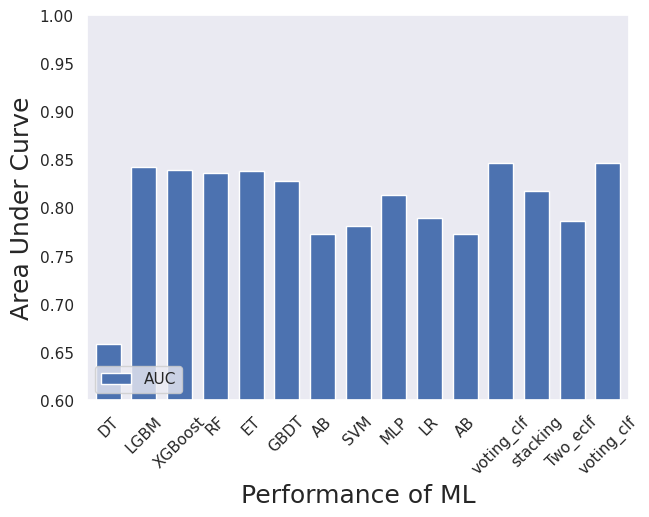

In [24]:
evals = ALL_eval.loc[['AUC'],:]
sns.set()
evals.T.plot.bar(figsize=(7,5),rot=45,width = 0.7,grid = False)
plt.ylim(0.6,1.0)
plt.ylabel('Area Under Curve',fontsize=18)
plt.xlabel('Performance of ML',fontsize=18)
plt.legend(loc =  'lower left' )

In [25]:
ALL_eval_test

,DT,LGBM,XGBoost,RF,ET,GBDT,AB,SVM,MLP,LR,AB,voting_clf,stacking,Two_eclf,voting_clf
ACC,0.700880,0.741935,0.739003,0.739003,0.733138,0.730205,0.645161,0.695015,0.706745,0.697947,0.645161,0.736070,0.727273,0.733138,0.736070
F1,0.689024,0.736527,0.735905,0.726154,0.721713,0.719512,0.629969,0.662338,0.710983,0.683077,0.629969,0.730539,0.719033,0.721713,0.730539
F2,0.676647,0.731272,0.734597,0.709135,0.707434,0.706587,0.617506,0.625767,0.720985,0.667067,0.617506,0.725327,0.710024,0.707434,0.725327
GMean,0.699869,0.741680,0.738938,0.737540,0.732016,0.729238,0.643879,0.688271,0.706620,0.696395,0.643879,0.735813,0.726709,0.732016,0.735813
SEN,0.668639,0.727811,0.733728,0.698225,0.698225,0.698225,0.609467,0.603550,0.727811,0.656805,0.609467,0.721893,0.704142,0.698225,0.721893
PREC,0.710692,0.745455,0.738095,0.756410,0.746835,0.742138,0.651899,0.733813,0.694915,0.711538,0.651899,0.739394,0.734568,0.746835,0.739394
SPEC,0.732558,0.755814,0.744186,0.779070,0.767442,0.761628,0.680233,0.784884,0.686047,0.738372,0.680233,0.750000,0.750000,0.767442,0.750000
MCC,0.402097,0.483858,0.477947,0.479012,0.466905,0.460885,0.290470,0.395223,0.414142,0.396598,0.290470,0.472121,0.454690,0.466905,0.472121
AUC,0.700599,0.830604,0.824481,0.803564,0.808277,0.807968,0.745253,0.756571,0.797785,0.764655,0.745253,0.826545,0.795548,0.762522,0.826545
AUPR,0.639419,0.850753,0.837567,0.822382,0.821071,0.836170,0.782479,0.781111,0.819814,0.778953,0.782479,0.844179,0.751804,0.700993,0.844179


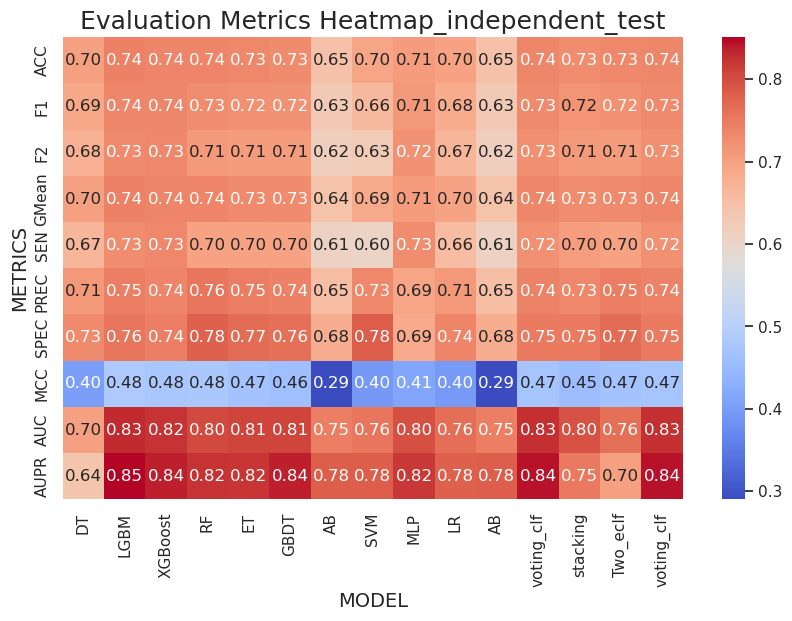

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming ALL_eval_test is a DataFrame with metrics as columns and models as rows

# Create a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(ALL_eval_test, cmap='coolwarm', annot=True, fmt=".2f", cbar=True)

plt.title('Evaluation Metrics Heatmap_independent_test', fontsize=18)
plt.xlabel('MODEL', fontsize=14)
plt.ylabel('METRICS',size=14)

plt.show()

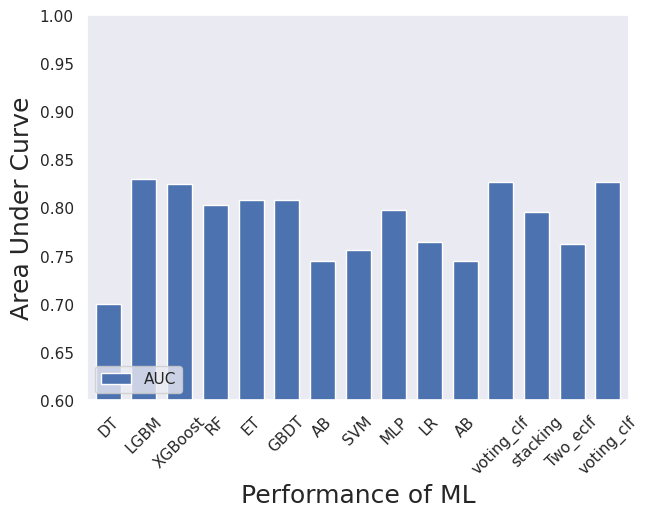

In [27]:
evals = ALL_eval_test.loc[['AUC'],:]
sns.set()
evals.T.plot.bar(figsize=(7,5),rot=45,width = 0.7,grid = False)
plt.ylim(0.6,1.0)
plt.ylabel('Area Under Curve',fontsize=18)
plt.xlabel('Performance of ML',fontsize=18)
plt.legend(loc =  'lower left' )

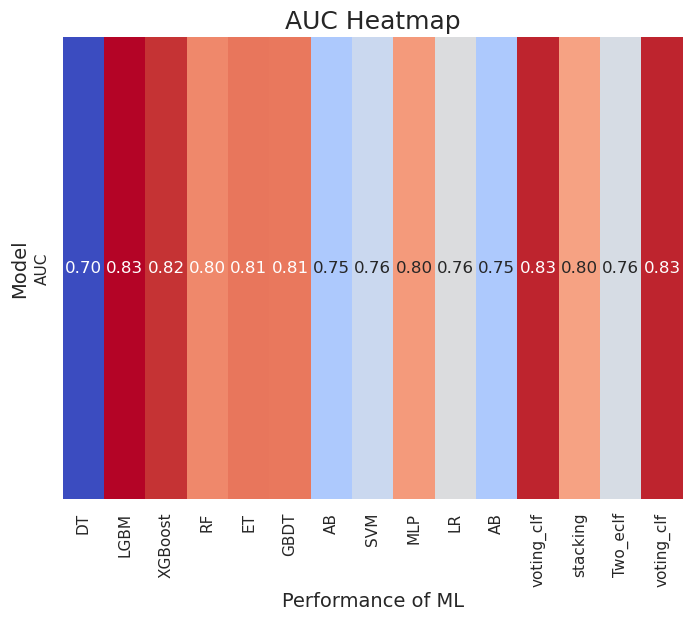

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming ALL_eval_test is a DataFrame containing AUC values
auc_data = ALL_eval_test.loc[['AUC'], :]

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(auc_data, cmap='coolwarm', annot=True, fmt=".2f", cbar=False)

plt.title('AUC Heatmap', fontsize=18)
plt.xlabel('Performance of ML', fontsize=14)
plt.ylabel('Model', fontsize=14)

plt.show()

In [29]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler 

In [30]:
#Scaling the train and test dataset for training
nms = MinMaxScaler()
X_train_norm = nms.fit_transform(X_train)
X_test_norm = nms.transform(X_test)
#standard scaling
stdsc = StandardScaler(with_mean=False)
X_train_std = stdsc.fit_transform(X_train)
X_test_std = stdsc.transform(X_test)

In [31]:
#Save the standarzied and normalixed data
X_train_norm1 = pd.DataFrame(X_train_norm)
X_train_norm1.to_csv('data/train/X_train_norm.csv',index=False)
X_test_norm1 = pd.DataFrame(X_test_norm)
X_test_norm1.to_csv('data/test/X_test_norm.csv',index=False)
#standarization
X_train_std1 = pd.DataFrame(X_train_std)
X_train_std1.to_csv('data/train/X_train_std.csv',index=False)
X_test_std1 = pd.DataFrame(X_test_std)
X_test_std1.to_csv('data/test/X_test_std.csv',index=False)

In [32]:
index = []
ALL_eval=pd.DataFrame()
for i in ml:
    print('process_{}'.format(i))
    model = eval(i)
    Evals = cv(model,X_train_std,y_train)
    ALL_eval = pd.concat([ALL_eval,Evals],axis=1)
    index.append("{}".format(i))
ALL_eval.columns = index

process_DT
process_LGBM
[LightGBM] [Info] Number of positive: 547, number of negative: 543
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.028106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 81180
[LightGBM] [Info] Number of data points in the train set: 1090, number of used features: 1169
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501835 -> initscore=0.007339
[LightGBM] [Info] Start training from score 0.007339
[LightGBM] [Info] Number of positive: 540, number of negative: 550
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.024135 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 80970
[LightGBM] [Info] Number of data points in the train set: 1090, number of used features: 1159
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.495413 -> initscore=-0.018349
[LightGBM] [Info] Start training from scor

In [33]:
index = []
ALL_eval=pd.DataFrame()
for i in ml:
    print('process_{}'.format(i))
    model = eval(i)
    Evals = cv(model,X_train_std,y_train)
    ALL_eval = pd.concat([ALL_eval,Evals],axis=1)
    index.append("{}".format(i))
ALL_eval.columns = index

process_DT
process_LGBM
[LightGBM] [Info] Number of positive: 547, number of negative: 543
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023272 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 81180
[LightGBM] [Info] Number of data points in the train set: 1090, number of used features: 1169
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501835 -> initscore=0.007339
[LightGBM] [Info] Start training from score 0.007339
[LightGBM] [Info] Number of positive: 540, number of negative: 550
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020940 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 80970
[LightGBM] [Info] Number of data points in the train set: 1090, number of used features: 1159
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.495413 -> initscore=-0.018349
[LightGBM] [Info] Start training from scor

In [34]:
ALL_eval

,DT,LGBM,XGBoost,RF,ET,GBDT,AB,SVM,MLP,LR,AB,voting_clf,stacking,Two_eclf,voting_clf
ACC,0.674203,0.768902,0.760809,0.764496,0.767440,0.752023,0.702125,0.758624,0.737357,0.697018,0.702125,0.768899,0.775506,0.771108,0.768899
F1,0.671167,0.757866,0.750704,0.749794,0.749995,0.740213,0.693202,0.739205,0.731948,0.699426,0.693202,0.755382,0.760589,0.758751,0.755382
F2,0.671558,0.741359,0.737281,0.727302,0.723210,0.724326,0.684630,0.709442,0.727036,0.705700,0.684630,0.734835,0.737348,0.739828,0.734835
GMean,0.671512,0.767889,0.758950,0.762324,0.764115,0.750198,0.701704,0.755010,0.737118,0.697090,0.701704,0.766822,0.772842,0.769782,0.766822
SEN,0.672243,0.730857,0.728754,0.713153,0.706516,0.714284,0.679152,0.691151,0.723960,0.710123,0.679152,0.721854,0.722796,0.727886,0.721854
PREC,0.672203,0.787654,0.774952,0.791156,0.800047,0.769148,0.708488,0.796349,0.740961,0.689830,0.708488,0.792871,0.803657,0.793372,0.792871
SPEC,0.673886,0.807055,0.791351,0.815305,0.827081,0.788768,0.725229,0.825768,0.750959,0.684700,0.725229,0.815098,0.827179,0.814541,0.815098
MCC,0.347656,0.539299,0.521847,0.531326,0.537837,0.504996,0.404672,0.522195,0.475119,0.394793,0.404672,0.539492,0.553371,0.544342,0.539492
AUC,0.673064,0.844090,0.839786,0.836450,0.838071,0.828167,0.772475,0.834356,0.820902,0.769283,0.772475,0.847004,0.816284,0.792397,0.847004
AUPR,0.614284,0.861842,0.860938,0.856364,0.854207,0.854595,0.792449,0.852244,0.829786,0.763053,0.792449,0.867860,0.785957,0.742334,0.867860


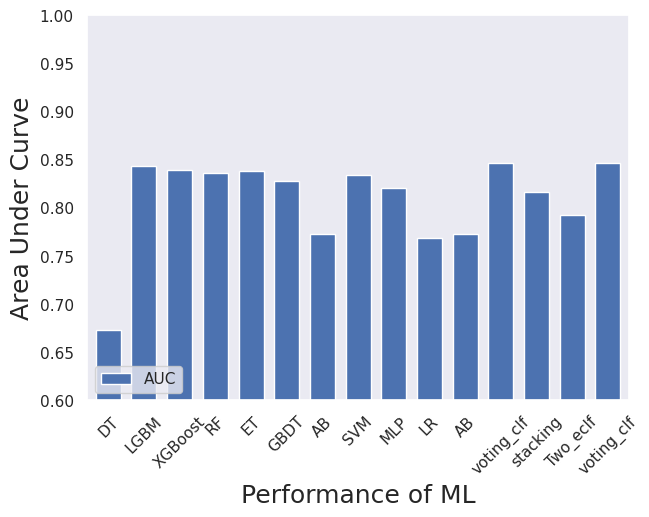

In [35]:
evals = ALL_eval.loc[['AUC'],:]
sns.set()
evals.T.plot.bar(figsize=(7,5),rot=45,width = 0.7,grid = False)
plt.ylim(0.6,1.0)
plt.ylabel('Area Under Curve',fontsize=18)
plt.xlabel('Performance of ML',fontsize=18)
plt.legend(loc =  'lower left' )

In [36]:
index = []
ALL_eval_test=pd.DataFrame()
for i in ml:
    eval_dict = []
    print('process_{}'.format(i))
    model = eval(i)
    model.fit(X_train_std,y_train)
    eval_dictionary = evaluate(X_test_std,y_test,model)
    eval_dict = eval_dict+[eval_dictionary]
    Evals = pd.DataFrame(eval_dict).T
    ALL_eval_test = pd.concat([ALL_eval_test,Evals],axis=1)
    index.append("{}".format(i))
ALL_eval_test.columns = index

process_DT
process_LGBM
[LightGBM] [Info] Number of positive: 676, number of negative: 687
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.028170 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 91817
[LightGBM] [Info] Number of data points in the train set: 1363, number of used features: 1206
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.495965 -> initscore=-0.016141
[LightGBM] [Info] Start training from score -0.016141
process_XGBoost
process_RF
process_ET
process_GBDT
process_AB
process_SVM
process_MLP
process_LR
process_AB
process_voting_clf
[LightGBM] [Info] Number of positive: 676, number of negative: 687
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.028334 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 91817
[LightGBM] [Info] Number of data points in the train set: 1363, number of used features

Processing SHAP for DT


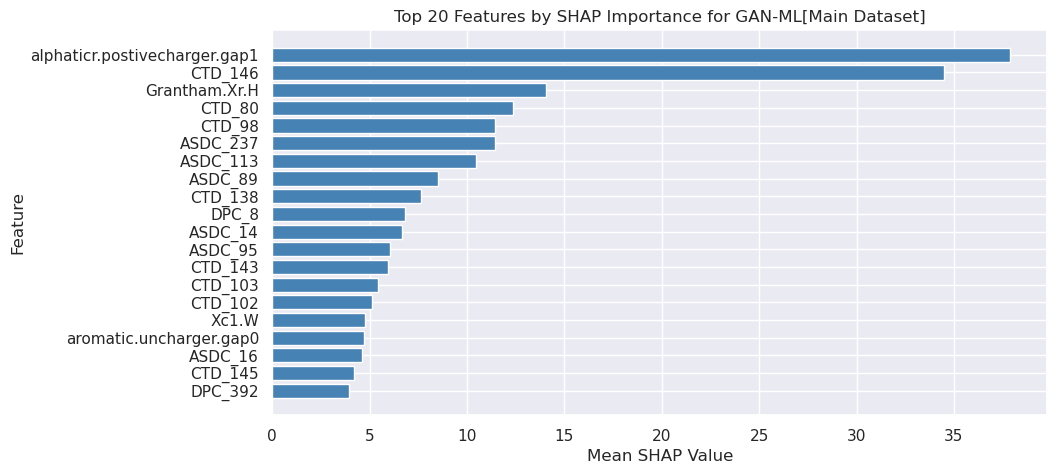

Processing SHAP for LGBM
[LightGBM] [Info] Number of positive: 676, number of negative: 687
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037205 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 91817
[LightGBM] [Info] Number of data points in the train set: 1363, number of used features: 1206
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.495965 -> initscore=-0.016141
[LightGBM] [Info] Start training from score -0.016141


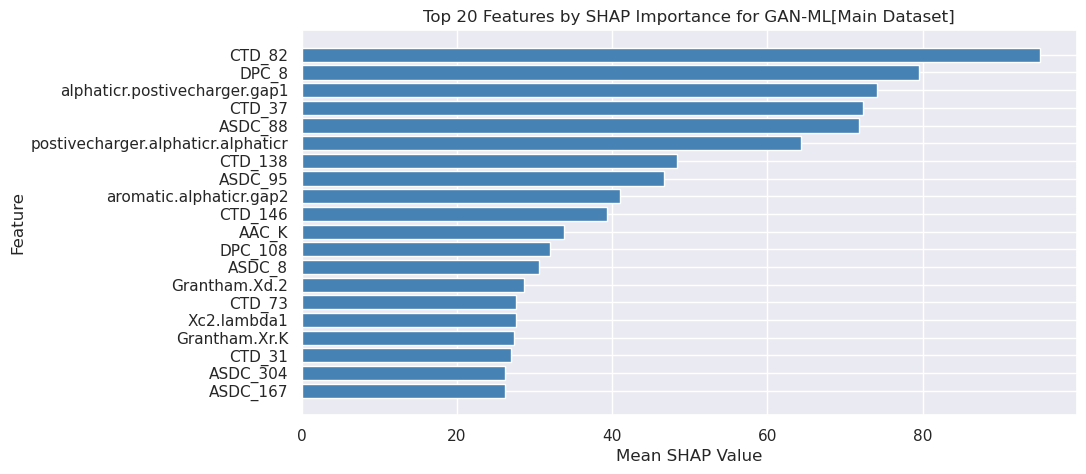

Processing SHAP for XGBoost


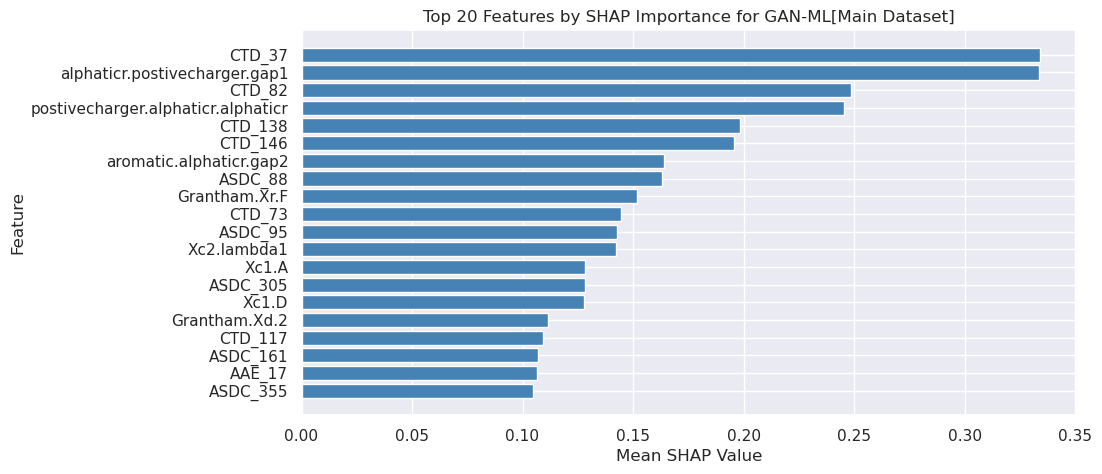

Processing SHAP for RF


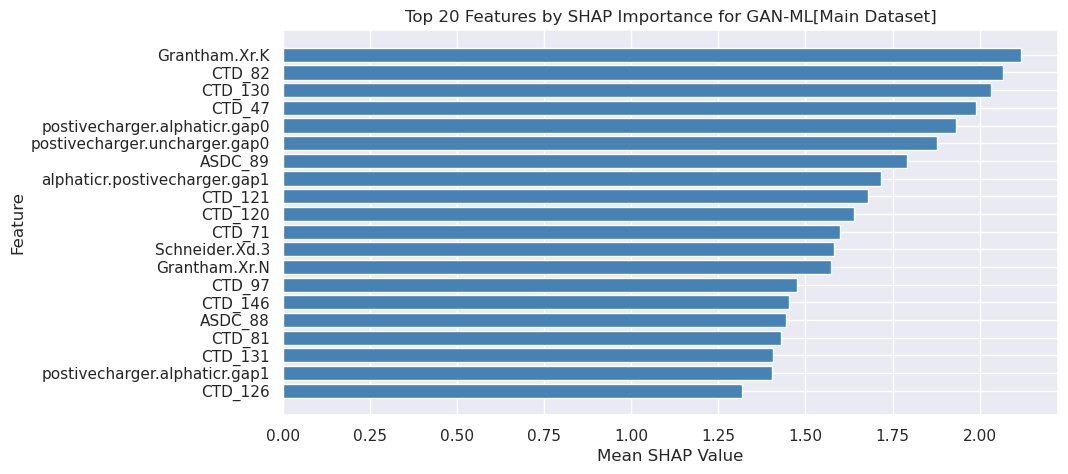

Processing SHAP for ET


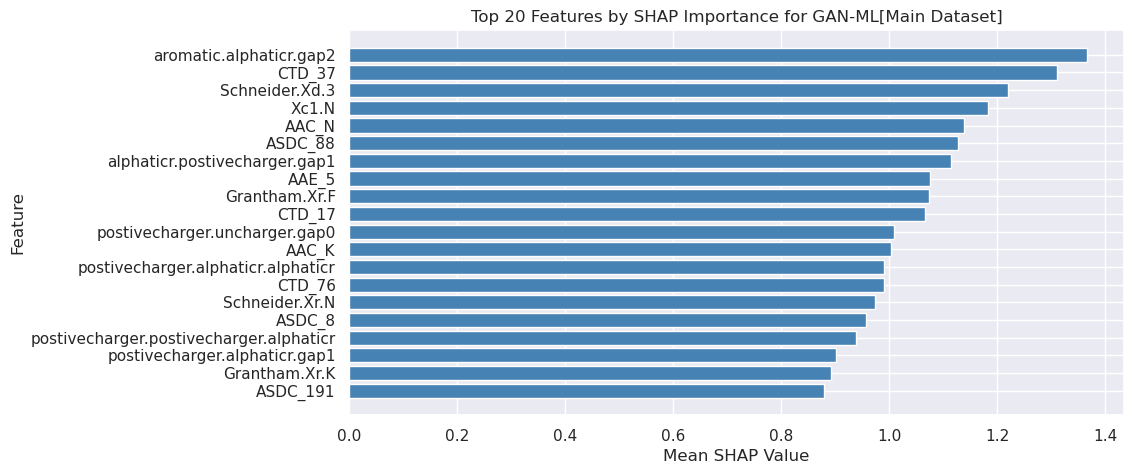

Processing SHAP for GBDT


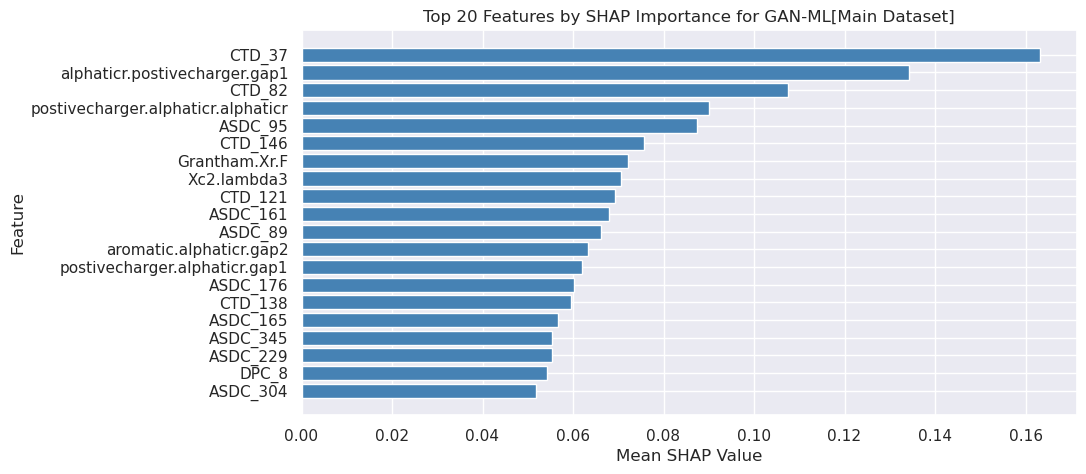

Processing SHAP for AB


InvalidModelError: Model type not yet supported by TreeExplainer: <class 'sklearn.ensemble._weight_boosting.AdaBoostClassifier'>

In [41]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Iterate through all models
for i in ml:
    print(f"Processing SHAP for {i}")
    
    model = eval(i)
    model.fit(X_train_std, y_train)
    
    # Use TreeExplainer for tree-based models, KernelExplainer for others
    if hasattr(model, "feature_importances_"):
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test_std)
    else:
        explainer = shap.KernelExplainer(model.predict, X_train_std)
        shap_values = explainer.shap_values(X_test_std)

    # Handling multi-class models (summing absolute SHAP values across classes)
    if isinstance(shap_values, list):  
        shap_values = np.abs(shap_values).mean(axis=0).sum(axis=0)
    else:
        shap_values = np.abs(shap_values).mean(axis=0)

    # Ensure feature names and SHAP values have the same length
    feature_importance_df = pd.DataFrame(
        {"Feature": fea[:len(shap_values)], "SHAP Value": shap_values}
    ).sort_values(by="SHAP Value", ascending=False)

    # Plot Top 20 Features
    plt.figure(figsize=(10, 5))
    plt.barh(feature_importance_df["Feature"][:20], feature_importance_df["SHAP Value"][:20], color="steelblue")
    plt.xlabel("Mean SHAP Value")
    plt.ylabel("Feature")
    plt.title(f"Top 20 Features by SHAP Importance for GAN-ML[Main Dataset]")
    plt.gca().invert_yaxis()  # Invert y-axis for highest importance at top
    plt.show()

In [37]:
ALL_eval_test

,DT,LGBM,XGBoost,RF,ET,GBDT,AB,SVM,MLP,LR,AB,voting_clf,stacking,Two_eclf,voting_clf
ACC,0.689150,0.736070,0.739003,0.733138,0.727273,0.730205,0.689150,0.718475,0.715543,0.648094,0.689150,0.730205,0.718475,0.730205,0.730205
F1,0.684524,0.727273,0.735905,0.720000,0.715596,0.708861,0.680723,0.705521,0.701538,0.661017,0.680723,0.721212,0.707317,0.716049,0.721212
F2,0.682088,0.716846,0.734597,0.703125,0.701439,0.680437,0.673421,0.690276,0.685096,0.679443,0.673421,0.710872,0.694611,0.697954,0.710872
GMean,0.689020,0.735392,0.738938,0.731663,0.726141,0.726544,0.688671,0.717155,0.714030,0.646997,0.688671,0.729521,0.717491,0.728530,0.729521
SEN,0.680473,0.710059,0.733728,0.692308,0.692308,0.662722,0.668639,0.680473,0.674556,0.692308,0.668639,0.704142,0.686391,0.686391,0.704142
PREC,0.688623,0.745342,0.738095,0.750000,0.740506,0.761905,0.693252,0.732484,0.730769,0.632432,0.693252,0.739130,0.729560,0.748387,0.739130
SPEC,0.697674,0.761628,0.744186,0.773256,0.761628,0.796512,0.709302,0.755814,0.755814,0.604651,0.709302,0.755814,0.750000,0.773256,0.755814
MCC,0.378213,0.472403,0.477947,0.467238,0.455143,0.463641,0.378293,0.437644,0.431918,0.298027,0.378293,0.460654,0.437370,0.461540,0.460654
AUC,0.689074,0.819905,0.824481,0.800795,0.807142,0.805938,0.780807,0.780515,0.786948,0.715873,0.780807,0.823001,0.794981,0.757414,0.823001
AUPR,0.626947,0.842642,0.837567,0.822137,0.820552,0.837259,0.813420,0.815548,0.819066,0.737104,0.813420,0.841227,0.751502,0.694791,0.841227


In [38]:
#Techniques for for downsampling and upsampling
#Downsampling
from imblearn.under_sampling import NearMiss,RandomUnderSampler,ClusterCentroids
from sklearn.linear_model import LogisticRegression

#Upsampling
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE

nm1 = NearMiss(version=1)
nm2 = NearMiss(version=2)
nm3 = NearMiss(version=3)
rus = RandomUnderSampler(random_state=seed,replacement=True)
cc = ClusterCentroids(random_state=seed)
smotee = SMOTEENN(random_state=10)
smote = SMOTE(random_state=seed)

In [39]:
baml = ['nm1','nm2','nm3','rus','cc','smotee','smote']
ml_eval = pd.DataFrame()
index = []
for i in baml:
    for m in ml:
        print('process_{}'.format(m))
        X_resampled ,y_resampled = eval(i).fit_resample(X_train,y_train)
        evals = cv(eval(m),X_resampled,y_resampled)
        ml_eval = pd.concat([ml_eval,evals],axis=1)
        index.append("{}_{}".format(i,m))
ml_eval.columns = index
ml_eval.to_csv('results/balance_eval_AUC/different_balance_ml.csv')

process_DT
process_LGBM
[LightGBM] [Info] Number of positive: 536, number of negative: 545
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.025836 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 80540
[LightGBM] [Info] Number of data points in the train set: 1081, number of used features: 1160
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.495837 -> initscore=-0.016652
[LightGBM] [Info] Start training from score -0.016652
[LightGBM] [Info] Number of positive: 539, number of negative: 542
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.025555 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 80610
[LightGBM] [Info] Number of data points in the train set: 1081, number of used features: 1171
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.498612 -> initscore=-0.005550
[LightGBM] [Info] Start training from sc

In [40]:
baml = ['nm1','nm2','nm3','rus','cc','smotee','smote']
ml_eval_test = []
index = []
for i in baml:
    for m in ml:
        print('process_{}'.format(m))
        X_resampled ,y_resampled = eval(i).fit_resample(X_train,y_train)
        eval(m).fit(X_resampled,y_resampled)
        evals = evaluate(X_test,y_test,eval(m))
        ml_eval_test = ml_eval_test + [evals]
        index.append("{}_{}".format(i,m))
ml_eval_test = pd.DataFrame(ml_eval_test).T
ml_eval_test.columns = index
ml_eval_test.to_csv('results/balance_eval_AUC/different_balance_ml_test.csv')

process_DT
process_LGBM
[LightGBM] [Info] Number of positive: 676, number of negative: 676
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.033516 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 91599
[LightGBM] [Info] Number of data points in the train set: 1352, number of used features: 1204
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
process_XGBoost
process_RF
process_ET
process_GBDT
process_AB
process_SVM
process_MLP
process_LR
process_AB
process_voting_clf
[LightGBM] [Info] Number of positive: 676, number of negative: 676
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.035587 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 91599
[LightGBM] [Info] Number of data points in the train set: 1352, number of used features: 1204
[LightGBM] [Info] [binary:BoostFromScore]: pavg=

In [41]:
#normalizing the dataset using Standard Scalra and Min-max scalar
from sklearn.preprocessing import MinMaxScaler, StandardScaler 

In [42]:
#Standarization and normalization of  train and test dataset
nms = MinMaxScaler()
X_train_norm = nms.fit_transform(X_train)
X_test_norm = nms.transform(X_test)
#STANDARIZATION
stdsc = StandardScaler(with_mean=False)
X_train_std = stdsc.fit_transform(X_train)
X_test_std = stdsc.transform(X_test)

In [43]:
#Normalization
X_train_norm1 = pd.DataFrame(X_train_norm)
X_train_norm1.to_csv('data/train/X_train_norm.csv',index=False)
X_test_norm1 = pd.DataFrame(X_test_norm)
X_test_norm1.to_csv('data/test/X_test_norm.csv',index=False)

#Standarization
X_train_std1 = pd.DataFrame(X_train_std)
X_train_std1.to_csv('data/train/X_train_std.csv',index=False)
X_test_std1 = pd.DataFrame(X_test_std)
X_test_std1.to_csv('data/test/X_test_std.csv',index=False)

In [44]:
X_train_norm = pd.read_csv('data/train/X_train_norm.csv').to_numpy()
X_test_norm = pd.read_csv('data/test/X_test_norm.csv').to_numpy()
X_train_std = pd.read_csv('data/train/X_train_std.csv').to_numpy()
X_test_std = pd.read_csv('data/test/X_test_std.csv').to_numpy()
y_train = pd.read_csv('data/train/y_train.csv').to_numpy()
y_test = pd.read_csv('data/test/y_test.csv').to_numpy()

In [45]:
baml = ['nm1','nm2','nm3','rus','cc','smotee','smote']
ml_eval = pd.DataFrame()
index = []
for i in baml:
    for m in ml:
        print('process_{}'.format(m))
        X_resampled ,y_resampled = eval(i).fit_resample(X_train_norm,y_train)
        evals = cv(eval(m),X_resampled,y_resampled)
        ml_eval = pd.concat([ml_eval,evals],axis=1)
        index.append("{}_{}".format(i,m))
ml_eval.columns = index
ml_eval.to_csv('results/balance_eval_AUC/different_balance_ml_norm.csv')

process_DT
process_LGBM
[LightGBM] [Info] Number of positive: 536, number of negative: 545
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.038378 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 80130
[LightGBM] [Info] Number of data points in the train set: 1081, number of used features: 1158
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.495837 -> initscore=-0.016652
[LightGBM] [Info] Start training from score -0.016652
[LightGBM] [Info] Number of positive: 539, number of negative: 542
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.027380 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 80337
[LightGBM] [Info] Number of data points in the train set: 1081, number of used features: 1167
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.498612 -> initscore=-0.005550
[LightGBM] [Info] Start training from sc

In [46]:
baml = ['nm1','nm2','nm3','rus','cc','smotee','smote']
ml_eval_test = []
index = []
for i in baml:
    for m in ml:
        print('process_{}'.format(m))
        X_resampled ,y_resampled = eval(i).fit_resample(X_train_std,y_train)
        eval(m).fit(X_resampled,y_resampled)
        evals = evaluate(X_test_std,y_test,eval(m))
        ml_eval_test = ml_eval_test + [evals]
        index.append("{}_{}".format(i,m))
ml_eval_test = pd.DataFrame(ml_eval_test).T
ml_eval_test.columns = index
ml_eval_test.to_csv('results/balance_eval_AUC/different_balance_ml_std_test.csv')

process_DT
process_LGBM
[LightGBM] [Info] Number of positive: 676, number of negative: 676
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.034482 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 91480
[LightGBM] [Info] Number of data points in the train set: 1352, number of used features: 1203
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
process_XGBoost
process_RF
process_ET
process_GBDT
process_AB
process_SVM
process_MLP
process_LR
process_AB
process_voting_clf
[LightGBM] [Info] Number of positive: 676, number of negative: 676
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037818 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 91480
[LightGBM] [Info] Number of data points in the train set: 1352, number of used features: 1203
[LightGBM] [Info] [binary:BoostFromScore]: pavg=